In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [7]:
# 1.	Data wrangling
print("Missing values per column:")
print(df.isna().sum())
print("\nTotal missing values:", df.isna().sum().sum())
print("\nData types and non-null counts:")
df.info()
print("\nSample of data:")
df.head()

Missing values per column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Total missing values: 0

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB

Sample of data:


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [30]:
#2.	Data analysis
# a.	Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis.

avg_sales = df['Sales'].mean()
avg_units = df['Unit'].mean()  

median_sales = df['Sales'].median()
median_units = df['Unit'].median()

mode_sales = df['Sales'].mode()
mode_units = df['Unit'].mode()

std_sales = df['Sales'].std()
std_units = df['Unit'].std()

print(f"Average Sales: {avg_sales}")
print(f"Average Units: {avg_units}")        
print(f"Median Sales: {median_sales}")
print(f"Median Units: {median_units}")
print(f"Mode Sales: {mode_sales.values}")
print(f"Mode Units: {mode_units.values}")
print(f"Standard Deviation of Sales: {std_sales}")
print(f"Standard Deviation of Units: {std_units}")

Average Sales: 45013.5582010582
Average Units: 18.00542328042328
Median Sales: 35000.0
Median Units: 14.0
Mode Sales: [22500]
Mode Units: [9]
Standard Deviation of Sales: 32253.506943966073
Standard Deviation of Units: 12.90140277758643


In [31]:
#Identify the group with the highest and lowest sales based on the data provided.
group_sales = df.groupby('Group')['Sales'].sum()
highest_sales_group = group_sales.idxmax()
lowest_sales_group = group_sales.idxmin()

print(f"Group with highest sales: {highest_sales_group} (${group_sales[highest_sales_group]:.2f})")
print(f"Group with lowest sales: {lowest_sales_group} (${group_sales[lowest_sales_group]:.2f})")

Group with highest sales:  Men ($85750000.00)
Group with lowest sales:  Seniors ($84037500.00)


In [32]:
# Generate weekly, monthly, and quarterly reports
# Reset index in case Date is set as index from previous runs
df.reset_index(inplace=True)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')

# Set Date as index for resampling
df.set_index('Date', inplace=True)

# Weekly sales
weekly_sales = df.resample('W')['Sales'].sum()
print("Weekly Sales Report:")
print(weekly_sales)

# Monthly sales
monthly_sales = df.resample('ME')['Sales'].sum()
print("\nMonthly Sales Report:")
print(monthly_sales)

# Quarterly sales (since data is 4th quarter, it will be one quarter)
quarterly_sales = df.resample('QE')['Sales'].sum()
print("\nQuarterly Sales Report:")
print(quarterly_sales)

# Reset index if needed for further analysis
df.reset_index(inplace=True)

Weekly Sales Report:
Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64

Monthly Sales Report:
Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64

Quarterly Sales Report:
Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64


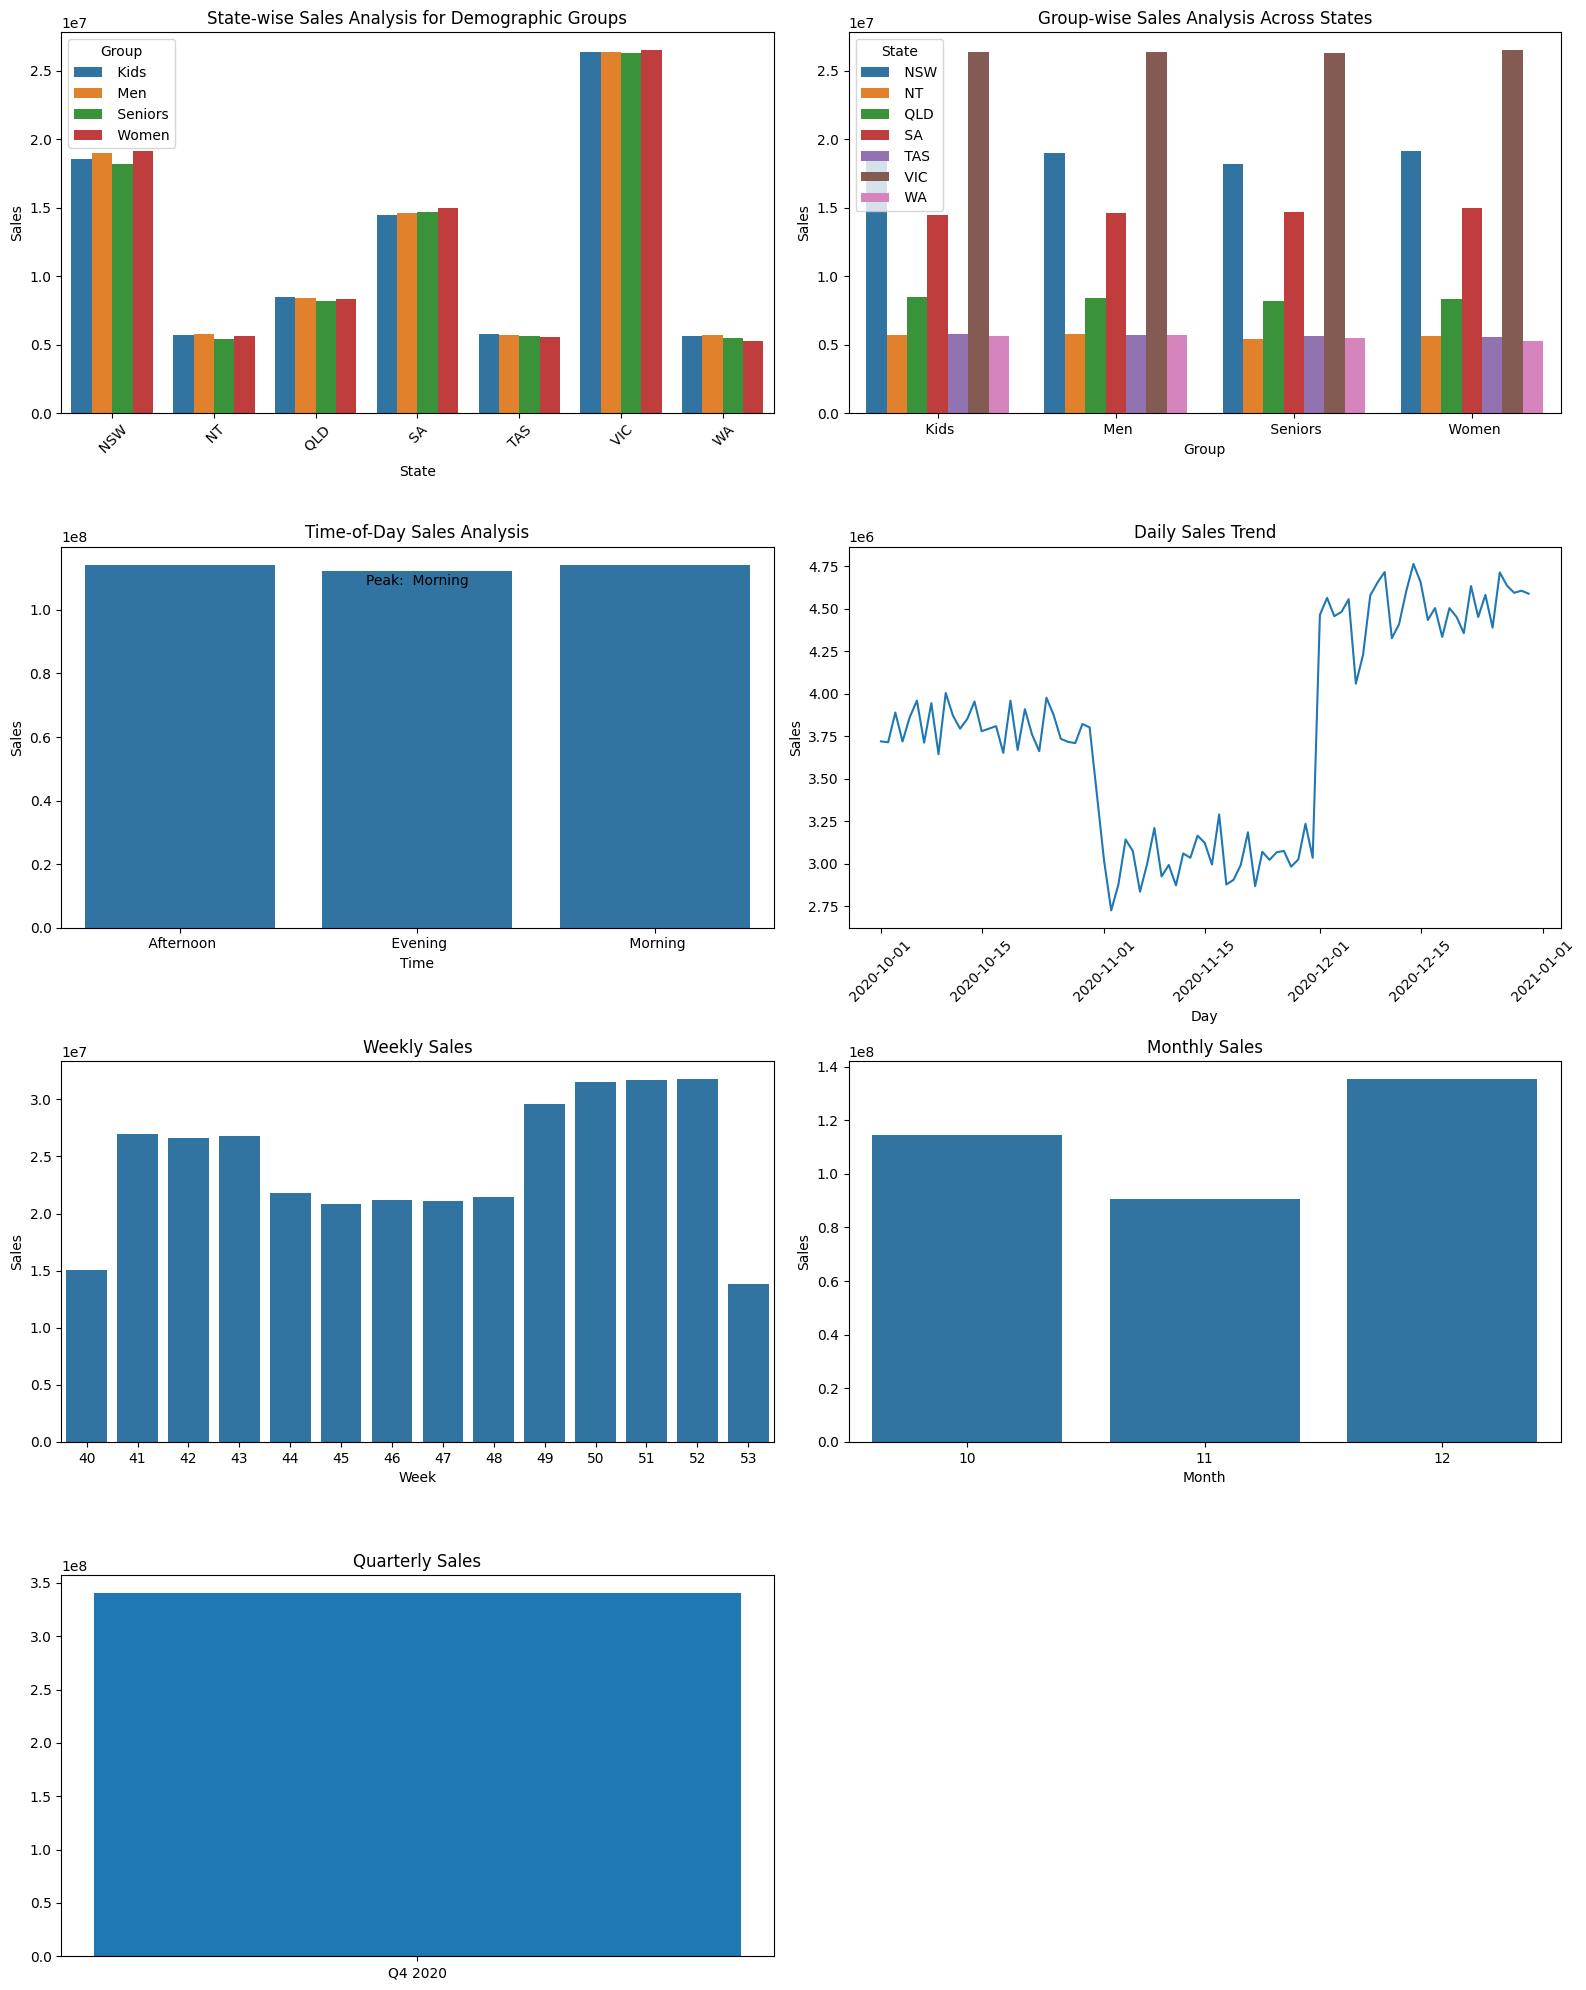

Recommendation: Seaborn is chosen for its statistical plotting capabilities, ease of use with pandas dataframes, and ability to create clear, informative visualizations.
 It supports hue for categorical differentiation, making it ideal for comparing groups and states.
 Matplotlib is used for subplots to arrange the dashboard. This ensures the visualizations are accessible and effective for decision-making by the head of S&M.


In [43]:
# 3. Data visualization

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Add columns
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.date

# Aggregate data
state_group_sales = df.groupby(['State', 'Group'])['Sales'].sum().reset_index()
group_state_sales = df.groupby(['Group', 'State'])['Sales'].sum().reset_index()
time_sales = df.groupby('Time')['Sales'].sum().reset_index()
daily_sales = df.groupby('Day')['Sales'].sum().reset_index().sort_values('Day')
weekly_sales = df.groupby('Week')['Sales'].sum().reset_index().sort_values('Week')
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index().sort_values('Month')
quarterly_sales = df['Sales'].sum()

# Create dashboard
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# 1. State-wise sales for demographic groups
sns.barplot(data=state_group_sales, x='State', y='Sales', hue='Group', ax=axes[0,0])
axes[0,0].set_title('State-wise Sales Analysis for Demographic Groups')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Group-wise sales across states
sns.barplot(data=group_state_sales, x='Group', y='Sales', hue='State', ax=axes[0,1])
axes[0,1].set_title('Group-wise Sales Analysis Across States')

# 3. Time-of-day analysis
sns.barplot(data=time_sales, x='Time', y='Sales', ax=axes[1,0])
axes[1,0].set_title('Time-of-Day Sales Analysis')
# Peak period
peak_time = time_sales.loc[time_sales['Sales'].idxmax(), 'Time']
axes[1,0].text(0.5, 0.9, f'Peak: {peak_time}', transform=axes[1,0].transAxes, ha='center')

# 4. Daily sales
sns.lineplot(data=daily_sales, x='Day', y='Sales', ax=axes[1,1])
axes[1,1].set_title('Daily Sales Trend')
axes[1,1].tick_params(axis='x', rotation=45)

# 5. Weekly sales
sns.barplot(data=weekly_sales, x='Week', y='Sales', ax=axes[2,0])
axes[2,0].set_title('Weekly Sales')

# 6. Monthly sales
sns.barplot(data=monthly_sales, x='Month', y='Sales', ax=axes[2,1])
axes[2,1].set_title('Monthly Sales')

# 7. Quarterly sales
axes[3,0].bar(['Q4 2020'], [quarterly_sales])
axes[3,0].set_title('Quarterly Sales')

# Hide empty subplot
axes[3,1].axis('off')

plt.tight_layout()
plt.show()

# Recommendation
print("Recommendation: Seaborn is chosen for its statistical plotting capabilities, ease of use with pandas dataframes, and ability to create clear, informative visualizations.\n It supports hue for categorical differentiation, making it ideal for comparing groups and states.\n Matplotlib is used for subplots to arrange the dashboard. This ensures the visualizations are accessible and effective for decision-making by the head of S&M.")


